In [ ]:
# ! pip install datasets transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


## Load the dataset.


In [ ]:
from datasets import load_dataset

dataset_name = "AI-Lab-Makerere/beans"
dataset = load_dataset(dataset_name)
dataset

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/bean_rust/bean_rust_train.75.jpg', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500 at 0x7C1C5F00AC80>, 'labels': 1}


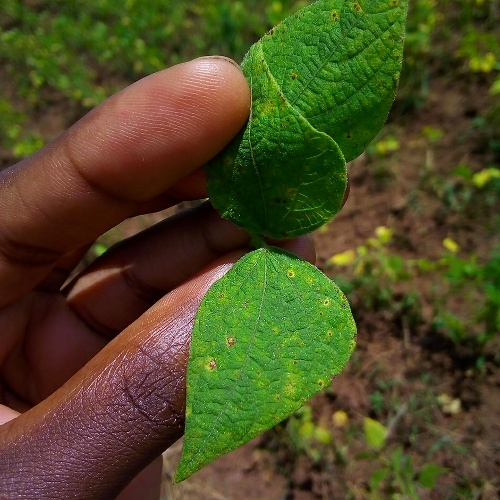

ClassLabel(names=['angular_leaf_spot', 'bean_rust', 'healthy'], id=None)
bean_rust


In [ ]:
from IPython.display import display

index = 666
example = dataset["train"][index]
print(example)

image = example["image"]
display(image)

labels = dataset["train"].features["labels"]
print(labels)

readable_label = labels.int2str(example["labels"])
print(readable_label)

## Loading the feature extractor.


In [ ]:
from transformers import ViTImageProcessor

model_name_or_path = 'google/vit-base-patch16-224-in21k'
feature_extractor = ViTImageProcessor.from_pretrained(model_name_or_path)

If we print a feature extractor, we can see its configuration.


In [ ]:
feature_extractor

ViTFeatureExtractor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTFeatureExtractor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

To process an image, simply pass it to the feature extractor's call function. This will return a dict containing `pixel values`, which is the numeric representation of your image that we'll pass to the model.

We get a numpy array by default, but if we add the `return_tensors='pt'` argument, we'll get back `torch` tensors instead.


In [ ]:
feature_extractor(image, return_tensors='pt')

{'pixel_values': tensor([[[[-0.3961, -0.3647, -0.2235,  ..., -0.1765, -0.0980, -0.0588],
          [-0.2549, -0.3882, -0.4275,  ..., -0.1608, -0.0980, -0.0667],
          [-0.1922, -0.1922, -0.3412,  ..., -0.1373, -0.1686, -0.0745],
          ...,
          [-0.6941, -0.7098, -0.7020,  ...,  0.0275,  0.0039, -0.0275],
          [-0.6941, -0.7098, -0.7098,  ...,  0.1294,  0.0902,  0.0039],
          [-0.6941, -0.7098, -0.6941,  ...,  0.2549,  0.2078,  0.0745]],

         [[-0.4118, -0.3647, -0.2314,  ..., -0.0902, -0.0039,  0.0353],
          [-0.2392, -0.3569, -0.3961,  ..., -0.0745, -0.0118,  0.0118],
          [-0.1608, -0.1373, -0.2784,  ..., -0.0431, -0.0824,  0.0118],
          ...,
          [-0.8510, -0.8745, -0.8902,  ..., -0.5294, -0.5373, -0.5608],
          [-0.8824, -0.8980, -0.8980,  ..., -0.4275, -0.4745, -0.5608],
          [-0.8980, -0.9059, -0.8902,  ..., -0.3098, -0.3647, -0.4980]],

         [[-0.6078, -0.6000, -0.4902,  ..., -0.3020, -0.2157, -0.1686],
          [-0

In [ ]:
feature = feature_extractor(image, return_tensors='pt')
feature['pixel_values'].shape

torch.Size([1, 3, 224, 224])

## Preprocess the dataset.


In [ ]:
def process_example(example):
    inputs = feature_extractor(example['image'], return_tensors='pt')
    inputs['labels'] = example['labels']
    return inputs

In [ ]:
process_example(dataset['train'][0])

{'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255],
          [-0

While we could call `ds.map` and apply this to every example at once, this can be very slow, especially if you use a larger dataset. Instead, we'll apply a **_transform_** to the dataset. Transforms are only applied to examples as you index them.

First, though, we'll need to update our last function to accept a batch of data, as that's what `ds.with_transform` expects.


In [ ]:
dataset = load_dataset(dataset_name)
dataset = dataset["train"]
dataset = dataset.train_test_split(0.2)

def transform(example_batch):
    # Take a list of PIL images and turn them to pixel values
    inputs = feature_extractor([x for x in example_batch['image']], return_tensors='pt')

    # Don't forget to include the labels!
    inputs['labels'] = example_batch['labels']
    return inputs

prepared_dataset = dataset.with_transform(transform)
prepared_dataset

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 827
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 207
    })
})

In [ ]:
# prepared_dataset = dataset.with_transform(transform)

In [ ]:
prepared_dataset["train"][0:2]

{'pixel_values': tensor([[[[-0.4980, -0.4824, -0.5216,  ..., -0.6314, -0.6314, -0.5373],
          [-0.4824, -0.4667, -0.5294,  ..., -0.6157, -0.6235, -0.4902],
          [-0.5216, -0.5137, -0.5373,  ..., -0.5922, -0.5686, -0.3882],
          ...,
          [-0.4745, -0.4667, -0.4667,  ..., -0.6706, -0.6863, -0.6941],
          [-0.3725, -0.3569, -0.3569,  ..., -0.6863, -0.6941, -0.6784],
          [-0.2706, -0.2549, -0.2392,  ..., -0.6784, -0.7255, -0.6941]],

         [[-0.1216, -0.1294, -0.1686,  ..., -0.2941, -0.2941, -0.2157],
          [-0.1137, -0.1059, -0.1765,  ..., -0.2863, -0.2941, -0.1608],
          [-0.1294, -0.1373, -0.1765,  ..., -0.2941, -0.2471, -0.0510],
          ...,
          [-0.3569, -0.3804, -0.3961,  ..., -0.8353, -0.8510, -0.8588],
          [-0.5137, -0.5294, -0.5529,  ..., -0.8588, -0.8745, -0.8588],
          [-0.6000, -0.6000, -0.5922,  ..., -0.8588, -0.8980, -0.8510]],

         [[-0.5922, -0.5922, -0.6235,  ..., -0.7412, -0.7020, -0.6078],
          [-0

## Training


In [ ]:
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [ ]:
!pip -q install evaluate

In [ ]:
import numpy as np
# from datasets import load_metric
from evaluate import load

metric = load("accuracy")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

## Load the pretrained Vision Transformer


In [ ]:
from transformers import ViTForImageClassification

labels = dataset['train'].features['labels'].names
print(labels)

model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)}
)

['angular_leaf_spot', 'bean_rust', 'healthy']


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./vit-base-beans-demo-v5",
  per_device_train_batch_size=128,
  eval_strategy="steps",
  num_train_epochs=4,
  fp16=True,
  save_steps=100,
  eval_steps=100,
  logging_steps=10,
  learning_rate=2e-4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='tensorboard',
  load_best_model_at_end=True,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_dataset["train"],
    eval_dataset=prepared_dataset["test"],
    processing_class=feature_extractor,
)

In [ ]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Step,Training Loss,Validation Loss


***** train metrics *****
  epoch                    =         4.0
  total_flos               = 238740629GF
  train_loss               =      0.3524
  train_runtime            =  0:01:02.39
  train_samples_per_second =      53.021
  train_steps_per_second   =       0.449


In [ ]:
metrics = trainer.evaluate(prepared_dataset['test'])
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =        4.0
  eval_accuracy           =     0.9758
  eval_loss               =     0.1392
  eval_runtime            = 0:00:03.47
  eval_samples_per_second =     59.583
  eval_steps_per_second   =      7.484


In [ ]:
import requests
import matplotlib.pyplot as plt
import urllib
import io
from PIL import Image

urls = [
    "http://2.bp.blogspot.com/_EWuR-VzwybY/TTgPAMlniYI/AAAAAAAAEmk/qFOyCxy9I34/s1600/P1015765.JPG",
    "https://upload.wikimedia.org/wikipedia/commons/a/ac/Soybean_leaves.jpg"
]

headers = {"User-Agent": "Mozilla/5.0"}

for url in urls:
    print(url)
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response:
        file = io.BytesIO(response.read())

    image = Image.open(file)
    plt.imshow(image)
    plt.show()

    #image = Image.open(requests.get(url, stream=False))
    features = feature_extractor(images=image, return_tensors="pt")
    print(features["pixel_values"].shape)
    pixel_values = features["pixel_values"].cuda()

    outputs = model(pixel_values)
    output = outputs[0].cpu().detach().numpy()[0]
    plt.show()

    logits = outputs.logits
    predicted_class_index = logits.argmax(-1).item()
    print(predicted_class_index)
    label = labels[predicted_class_index]
    print(label)
    print("")
